# Fitting Galaxy Spectra: From Mock to Posterior in Seconds

Spectra contain orders of magnitude more information than photometry. A
200-pixel spectrum constrains ~40× more than 5-band photometry — breaking
degeneracies that plague broadband fitting. This notebook demonstrates
spectroscopic fitting with tengri: parametric and stochastic models,
photometry vs spectroscopy comparison, SNR dependence, and redshift
accessibility.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    ParamSpec,
    Uniform,
    load_filter_set,
    load_ssp_data,
)

import sys, os  # noqa: E401, E402
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("demonstrations", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (  # noqa: E402
    COLORS,
    SPECTRAL_FEATURES,
    convergence_table,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

In [2]:
ssp_data = load_ssp_data(
    "data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
)
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)

In [3]:
# Parametric model (D = 7)
spec_param = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)
model_param = Model(spec_param, ssp_data, filters=filters)
model_param.precompute_spectroscopy(WAVE_OBS)

key = jax.random.PRNGKey(42)
true_param = spec_param.sample(key)
mock_spec = model_param.mock_spectrum(true_param, WAVE_OBS, snr=30.0, key=key)
mock_phot = model_param.mock(true_param, snr=20.0, key=jax.random.fold_in(key, 1))

W0321 13:20:10.974679 14663949 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_3632/3512012687.py:15: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_param = Model(spec_param, ssp_data, filters=filters)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_3632/3512012687.py:16: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_param.precompute_spectroscopy(WAVE_OBS)


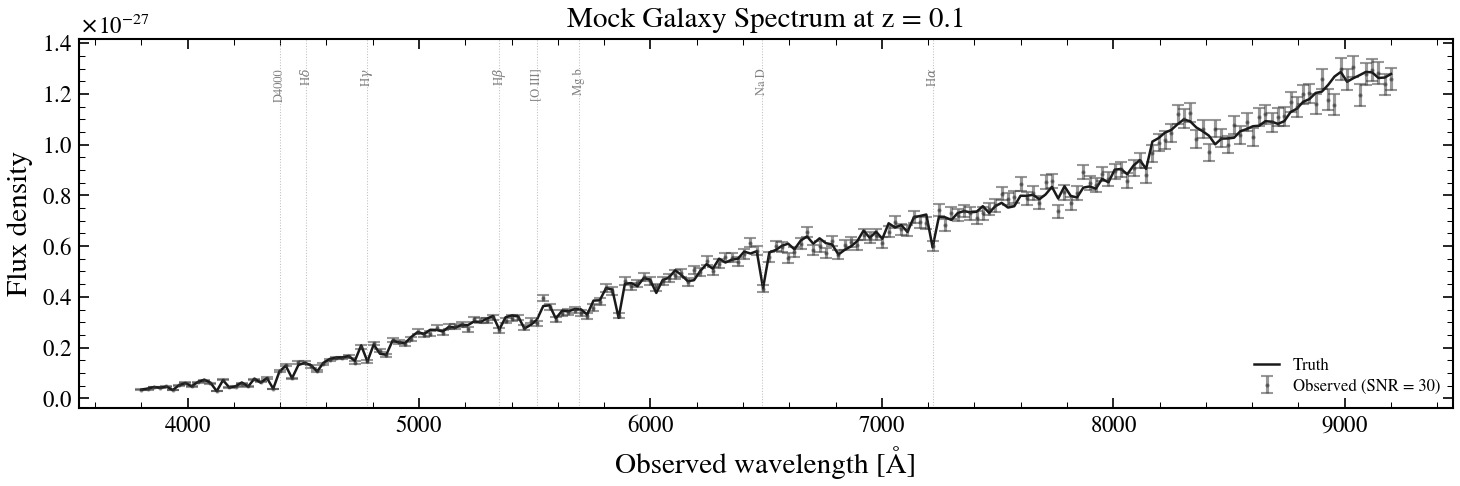

In [4]:
# --- FIGURE 1: Mock spectrum with annotated features ---
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.errorbar(
    np.array(WAVE_OBS), np.array(mock_spec.flux_obs), yerr=np.array(mock_spec.noise),
    fmt=".", ms=2, color=COLORS["data"], alpha=0.5, label="Observed (SNR = 30)",
)
ax.plot(np.array(WAVE_OBS), np.array(mock_spec.flux_true), color=COLORS["truth"], lw=1.2, label="Truth")

for feat_name, feat_wave in SPECTRAL_FEATURES.items():
    w_obs = feat_wave * 1.1  # z = 0.1
    if 3800 < w_obs < 9200:
        ax.axvline(w_obs, color="grey", ls=":", lw=0.5, alpha=0.5)
        ax.text(w_obs, ax.get_ylim()[1] * 0.92, feat_name,
                fontsize=6, ha="center", va="top", rotation=90, color="grey")

ax.set_xlabel("Observed wavelength [Å]")
ax.set_ylabel("Flux density")
ax.legend(fontsize=8)
ax.set_title("Mock Galaxy Spectrum at z = 0.1")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_mock_spectrum.png"), dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Fit parametric model with native_geovi
fitter_spec = Fitter(
    model_param, mock_spec.flux_obs, mock_spec.noise, data_type="spectroscopy"
)
fitter_spec.compile(verbose=False)  # pre-compile (not timed)

t0 = time.perf_counter()
result_map = fitter_spec.run("map", n_steps=500, verbose=False)
result_geovi_spec = fitter_spec.run(
    "native_geovi", n_iterations=15, n_samples=6, n_seeds=5,
    n_posterior_samples=5000, verbose=False,
)
t_spec = time.perf_counter() - t0
print(f"Spectroscopic fit: {t_spec:.1f}s")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0321 13:20:15.201824 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 13:20:16.552016 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 13:21:25.624448 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 13:21:40.942759 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Spectroscopic fit: 152.1s


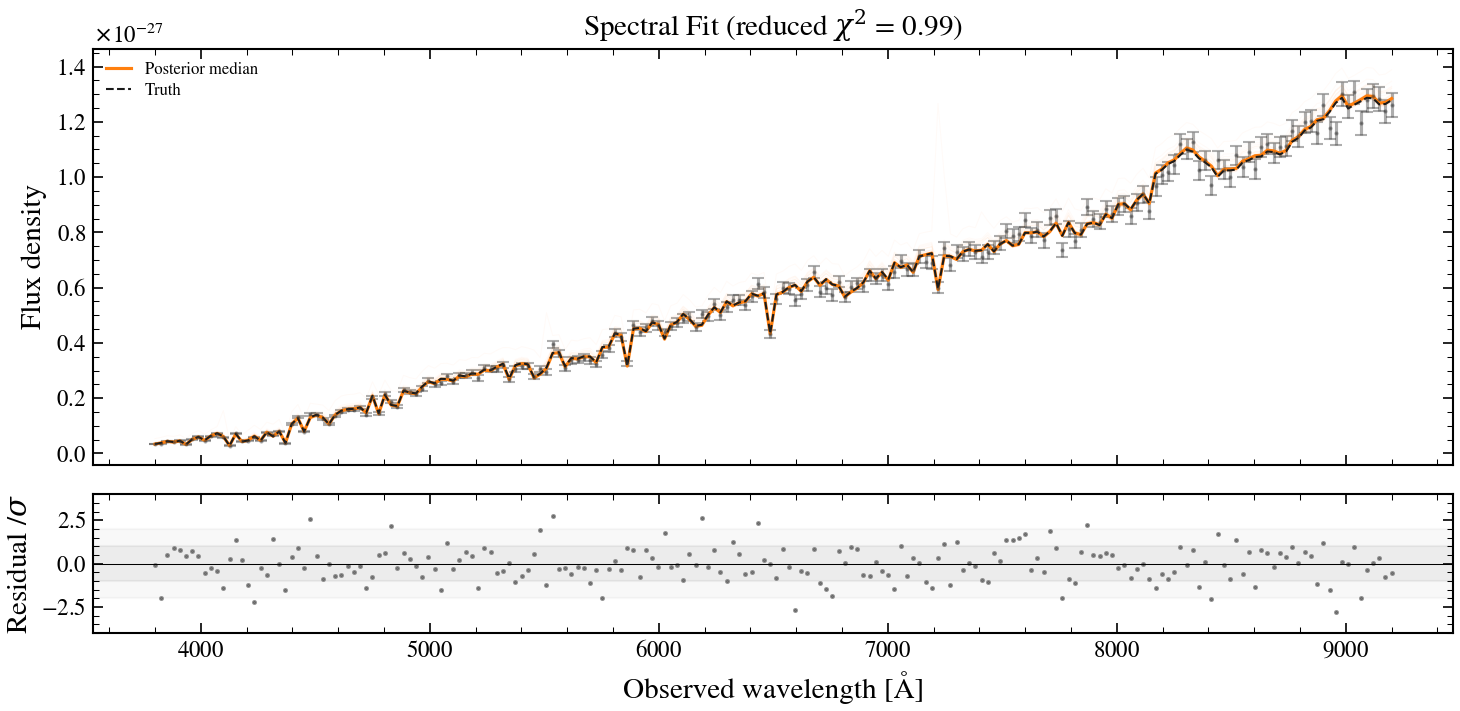

In [6]:
# --- FIGURE 2: Spectral fit + residuals ---
spec_draws = []
for i in range(50):
    idx = i % len(result_geovi_spec.samples[spec_param.free_params[0]])
    draw = {k: v[idx] for k, v in result_geovi_spec.samples.items()}
    spec_draws.append(np.array(model_param.predict_spectrum(draw)))
spec_draws = np.array(spec_draws)
spec_med = np.median(spec_draws, axis=0)

fig, (ax_f, ax_r) = plt.subplots(
    2, 1, figsize=(10, 5), gridspec_kw={"height_ratios": [3, 1]}, sharex=True
)
w = np.array(WAVE_OBS)
ax_f.errorbar(w, np.array(mock_spec.flux_obs), yerr=np.array(mock_spec.noise),
              fmt=".", ms=2, color=COLORS["data"], alpha=0.4)
for s in spec_draws[:50]:
    ax_f.plot(w, s, color=COLORS["geovi"], alpha=0.03, lw=0.5)
ax_f.plot(w, spec_med, color=COLORS["geovi"], lw=1.5, label="Posterior median")
ax_f.plot(w, np.array(mock_spec.flux_true), color=COLORS["truth"], lw=1, ls="--", label="Truth")
ax_f.legend(fontsize=8)
ax_f.set_ylabel("Flux density")

res = (np.array(mock_spec.flux_obs) - spec_med) / np.array(mock_spec.noise)
ax_r.scatter(w, res, s=2, c=COLORS["data"], alpha=0.5)
ax_r.axhline(0, color="k", lw=0.5)
ax_r.axhspan(-1, 1, alpha=0.1, color="grey")
ax_r.axhspan(-2, 2, alpha=0.05, color="grey")
ax_r.set_ylim(-4, 4)
ax_r.set_ylabel(r"Residual /$\sigma$")
ax_r.set_xlabel("Observed wavelength [Å]")

chi2 = np.sum(res**2) / len(res)
ax_f.set_title(f"Spectral Fit (reduced $\\chi^2$ = {chi2:.2f})")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig02_spectral_fit.png"), dpi=150, bbox_inches="tight")
plt.show()

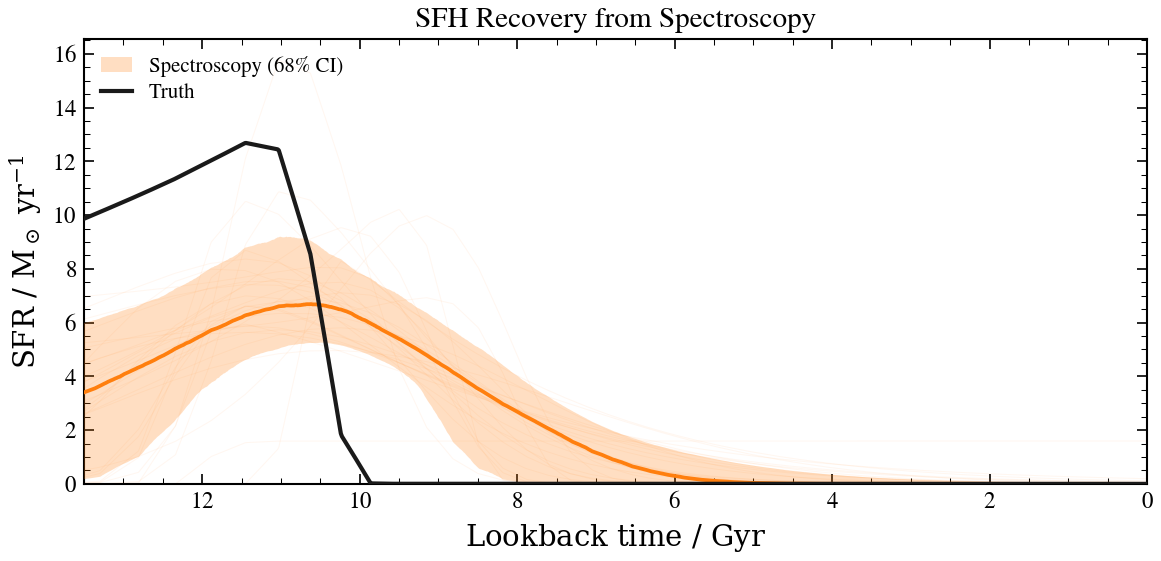

In [7]:
# --- FIGURE 3: SFH recovery ---
fig, ax = plt.subplots(figsize=(8, 4))
plot_sfh(model_param, result_geovi_spec, true_params=true_param, ax=ax,
         color=COLORS["geovi"], label="Spectroscopy", method="geoVI")
ax.set_title("SFH Recovery from Spectroscopy")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig03_sfh_spec.png"), dpi=150, bbox_inches="tight")
plt.show()

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

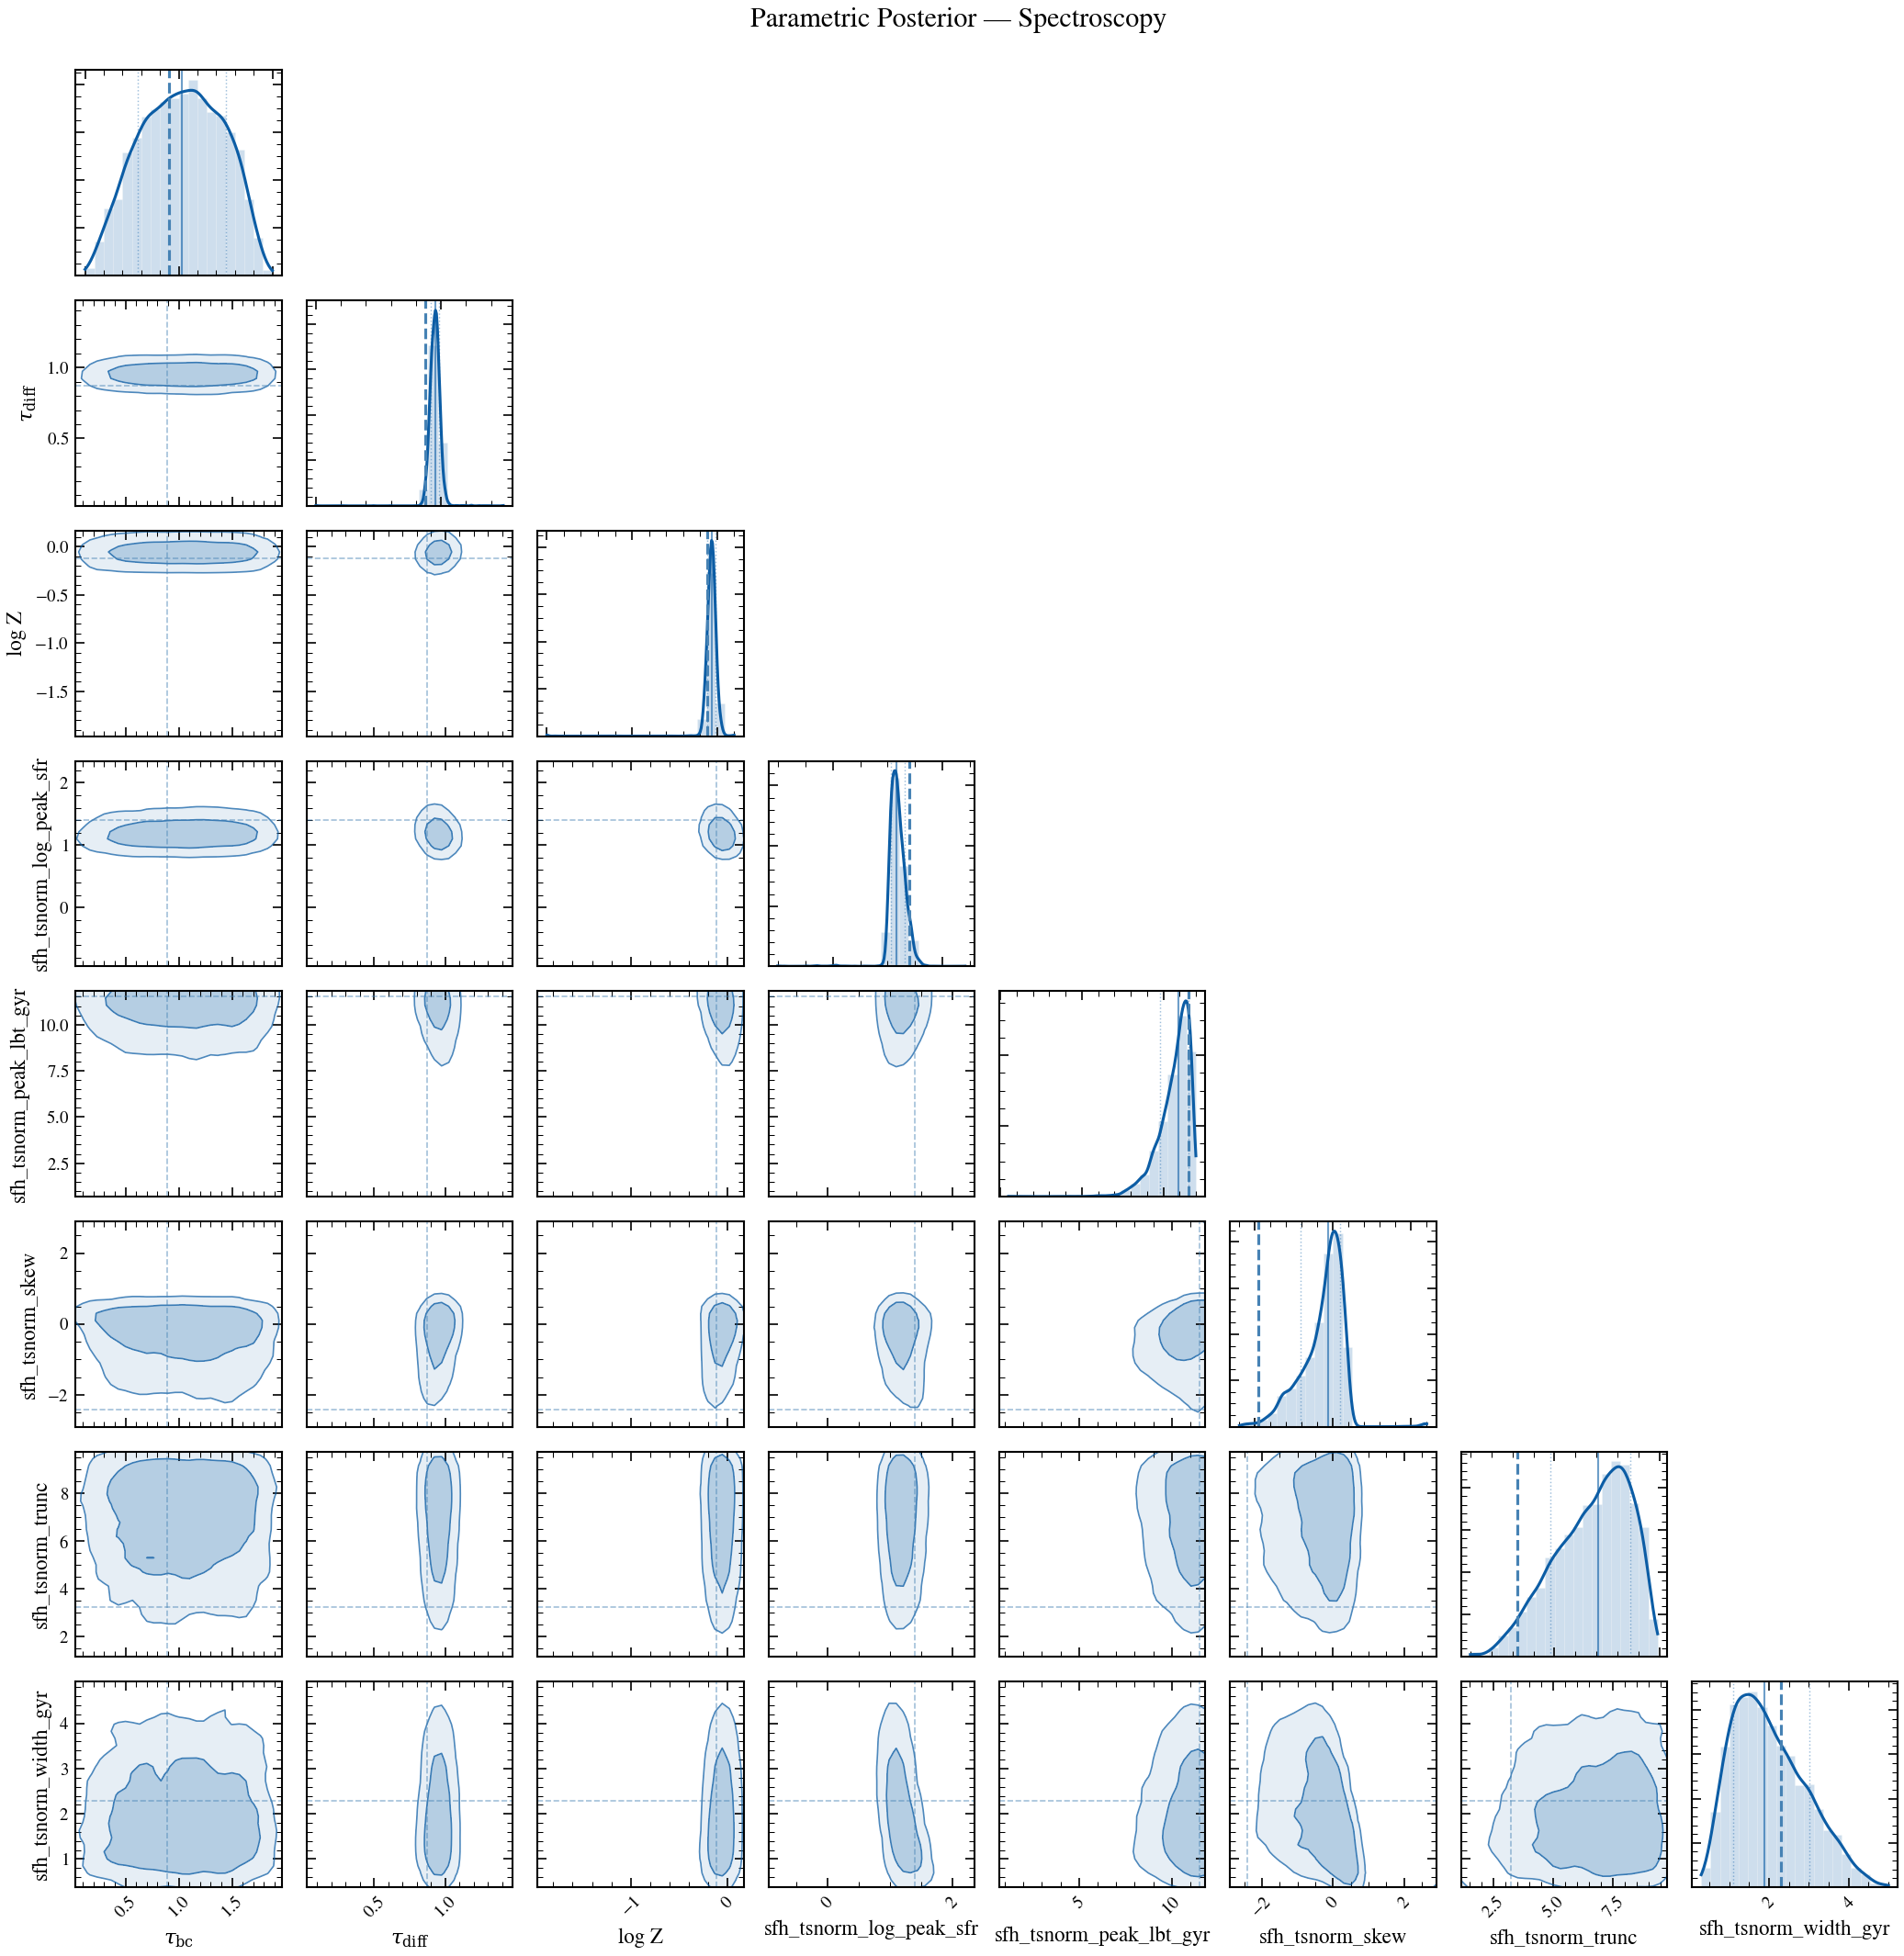

In [8]:
# --- FIGURE 4: Corner plot ---
fig = safe_corner(result_geovi_spec, truths=true_param)
if fig is not None:
    fig.suptitle("Parametric Posterior — Spectroscopy", y=1.02)
    plt.savefig(os.path.join(FIGDIR, "fig04_corner_spec.png"), dpi=150, bbox_inches="tight")
plt.show()

## Stochastic SFH from Spectroscopy

Spectroscopy breaks the σ–τ degeneracy that photometry can't. The rich
spectral information constrains both the amplitude and timescale of
burstiness.

In [9]:
# Stochastic model
spec_stoch = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    sfh_field_psd_sigma=Uniform(0.1, 4.0),
    sfh_field_psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type=["tsnorm", "field"],
    n_grid=128,
)
model_stoch = Model(spec_stoch, ssp_data, filters=filters)
model_stoch.precompute_spectroscopy(WAVE_OBS)

true_stoch = spec_stoch.sample(jax.random.PRNGKey(77))
true_stoch = {**true_stoch}
true_stoch["sfh_field_psd_sigma"] = jnp.array(2.0)
true_stoch["sfh_field_psd_tau_myr"] = jnp.array(20.0)

mock_spec_s = model_stoch.mock_spectrum(
    true_stoch, WAVE_OBS, snr=30.0, key=jax.random.PRNGKey(78)
)
mock_phot_s = model_stoch.mock(true_stoch, snr=20.0, key=jax.random.PRNGKey(79))

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_3632/380209066.py:18: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_stoch = Model(spec_stoch, ssp_data, filters=filters)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_3632/380209066.py:19: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_stoch.precompute_spectroscopy(WAVE_OBS)


In [10]:
fitter_stoch_spec = Fitter(
    model_stoch, mock_spec_s.flux_obs, mock_spec_s.noise, data_type="spectroscopy"
)
fitter_stoch_spec.compile(verbose=False)  # pre-compile (not timed)

t0 = time.perf_counter()
_ = fitter_stoch_spec.run("map", n_steps=1000, verbose=False)
result_stoch_spec = fitter_stoch_spec.run(
    "native_geovi", n_iterations=20, n_samples=6, n_seeds=5,
    n_posterior_samples=5000, verbose=False,
)
t_stoch_spec = time.perf_counter() - t0
print(f"Stochastic spectroscopic fit (D = {spec_stoch.n_free}): {t_stoch_spec:.1f}s")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0321 13:24:11.811048 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 13:24:14.145769 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 13:25:57.676051 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 13:26:19.197079 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Stochastic spectroscopic fit (D = 10): 141.3s


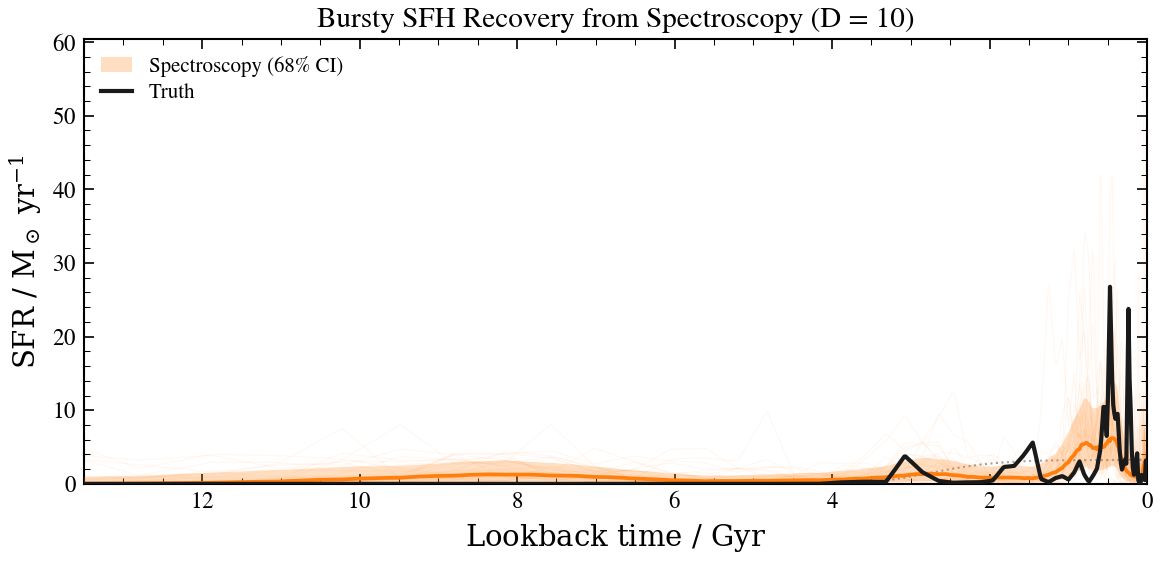

In [11]:
# --- FIGURE 5: Bursty SFH recovery from spectroscopy ---
fig, ax = plt.subplots(figsize=(8, 4))
plot_sfh(model_stoch, result_stoch_spec, true_params=true_stoch, ax=ax,
         color=COLORS["geovi"], label="Spectroscopy", method="geoVI",
         show_mean_sfh=True)
ax.set_title(f"Bursty SFH Recovery from Spectroscopy (D = {spec_stoch.n_free})")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig05_sfh_bursty_spec.png"), dpi=150, bbox_inches="tight")
plt.show()

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

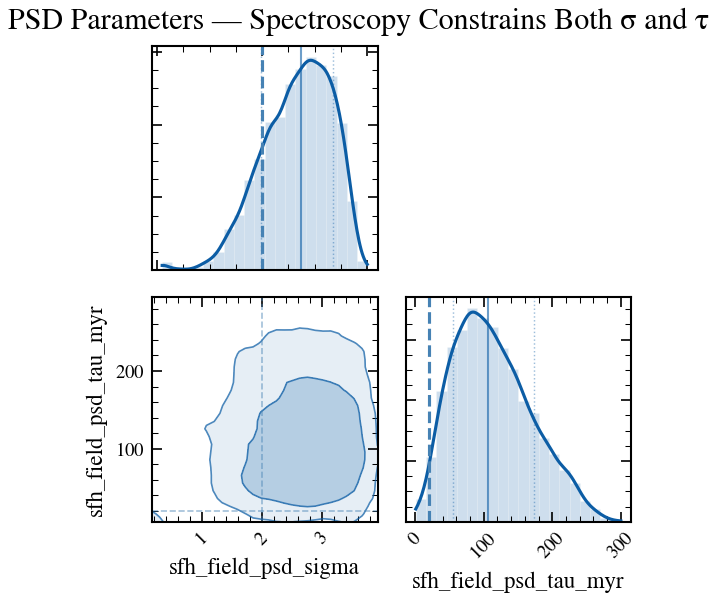

In [12]:
# --- FIGURE 6: PSD parameter corner ---
psd_params = ["sfh_field_psd_sigma", "sfh_field_psd_tau_myr"]
fig = safe_corner(result_stoch_spec, truths=true_stoch, params=psd_params)
if fig is not None:
    fig.suptitle("PSD Parameters — Spectroscopy Constrains Both σ and τ", y=1.02)
    plt.savefig(os.path.join(FIGDIR, "fig06_psd_corner.png"), dpi=150, bbox_inches="tight")
plt.show()

## Photometry vs Spectroscopy: Head-to-Head

We fit the same galaxy with 5-band SDSS photometry and compare posteriors.

In [13]:
# Fit photometry
fitter_stoch_phot = Fitter(
    model_stoch, mock_phot_s.flux_obs, mock_phot_s.noise, data_type="photometry"
)
_ = fitter_stoch_phot.run("map", n_steps=1000, verbose=False)
result_stoch_phot = fitter_stoch_phot.run(
    "native_geovi", n_iterations=20, n_samples=6, n_seeds=5,
    n_posterior_samples=5000, verbose=False,
)

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0321 13:28:24.674306 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 13:28:42.778902 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


/Users/suchethacooray/Projects/diffsed/src/tengri/inference/fitter.py:1935: UserWarning: Seeds disagree: H = 8.9 ± 3.0 (CV=33%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_native_vi(


W0321 13:28:53.180223 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


/Users/suchethacooray/Projects/diffsed/src/tengri/inference/fitter.py:1935: UserWarning: Poor fit: chi2/dof=12.5 (expected ~1)
  return self._run_native_vi(


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

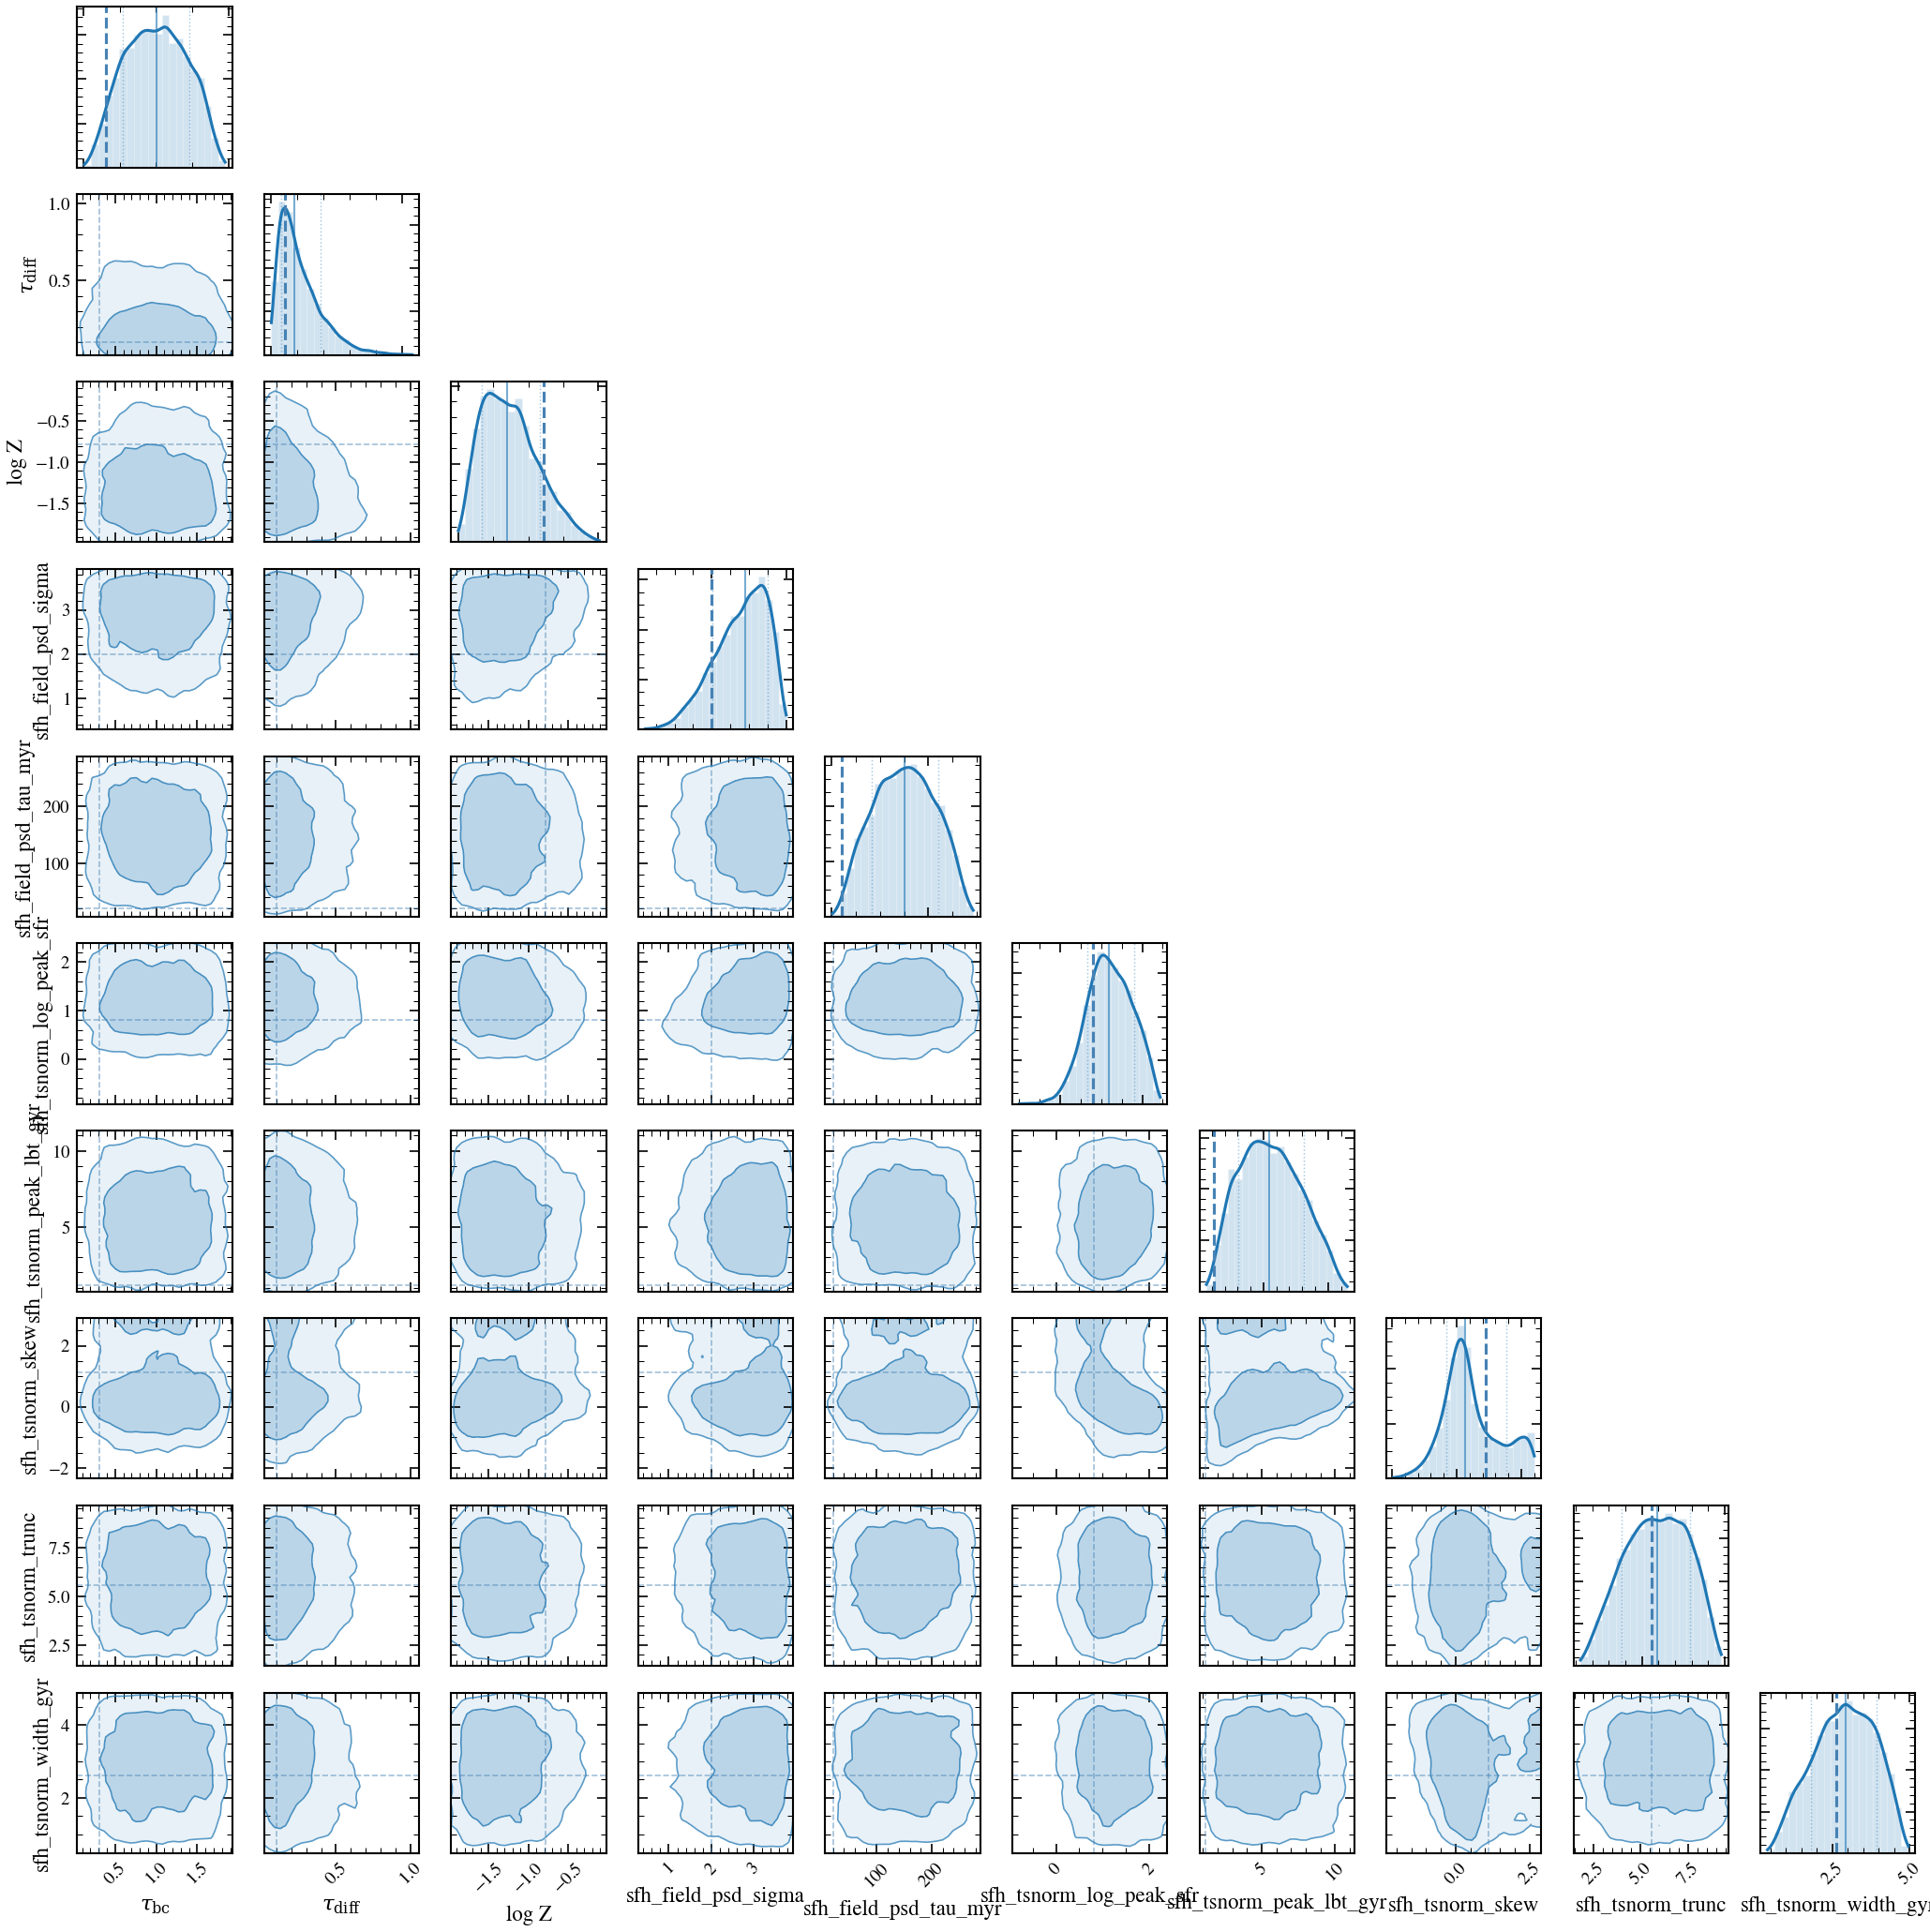

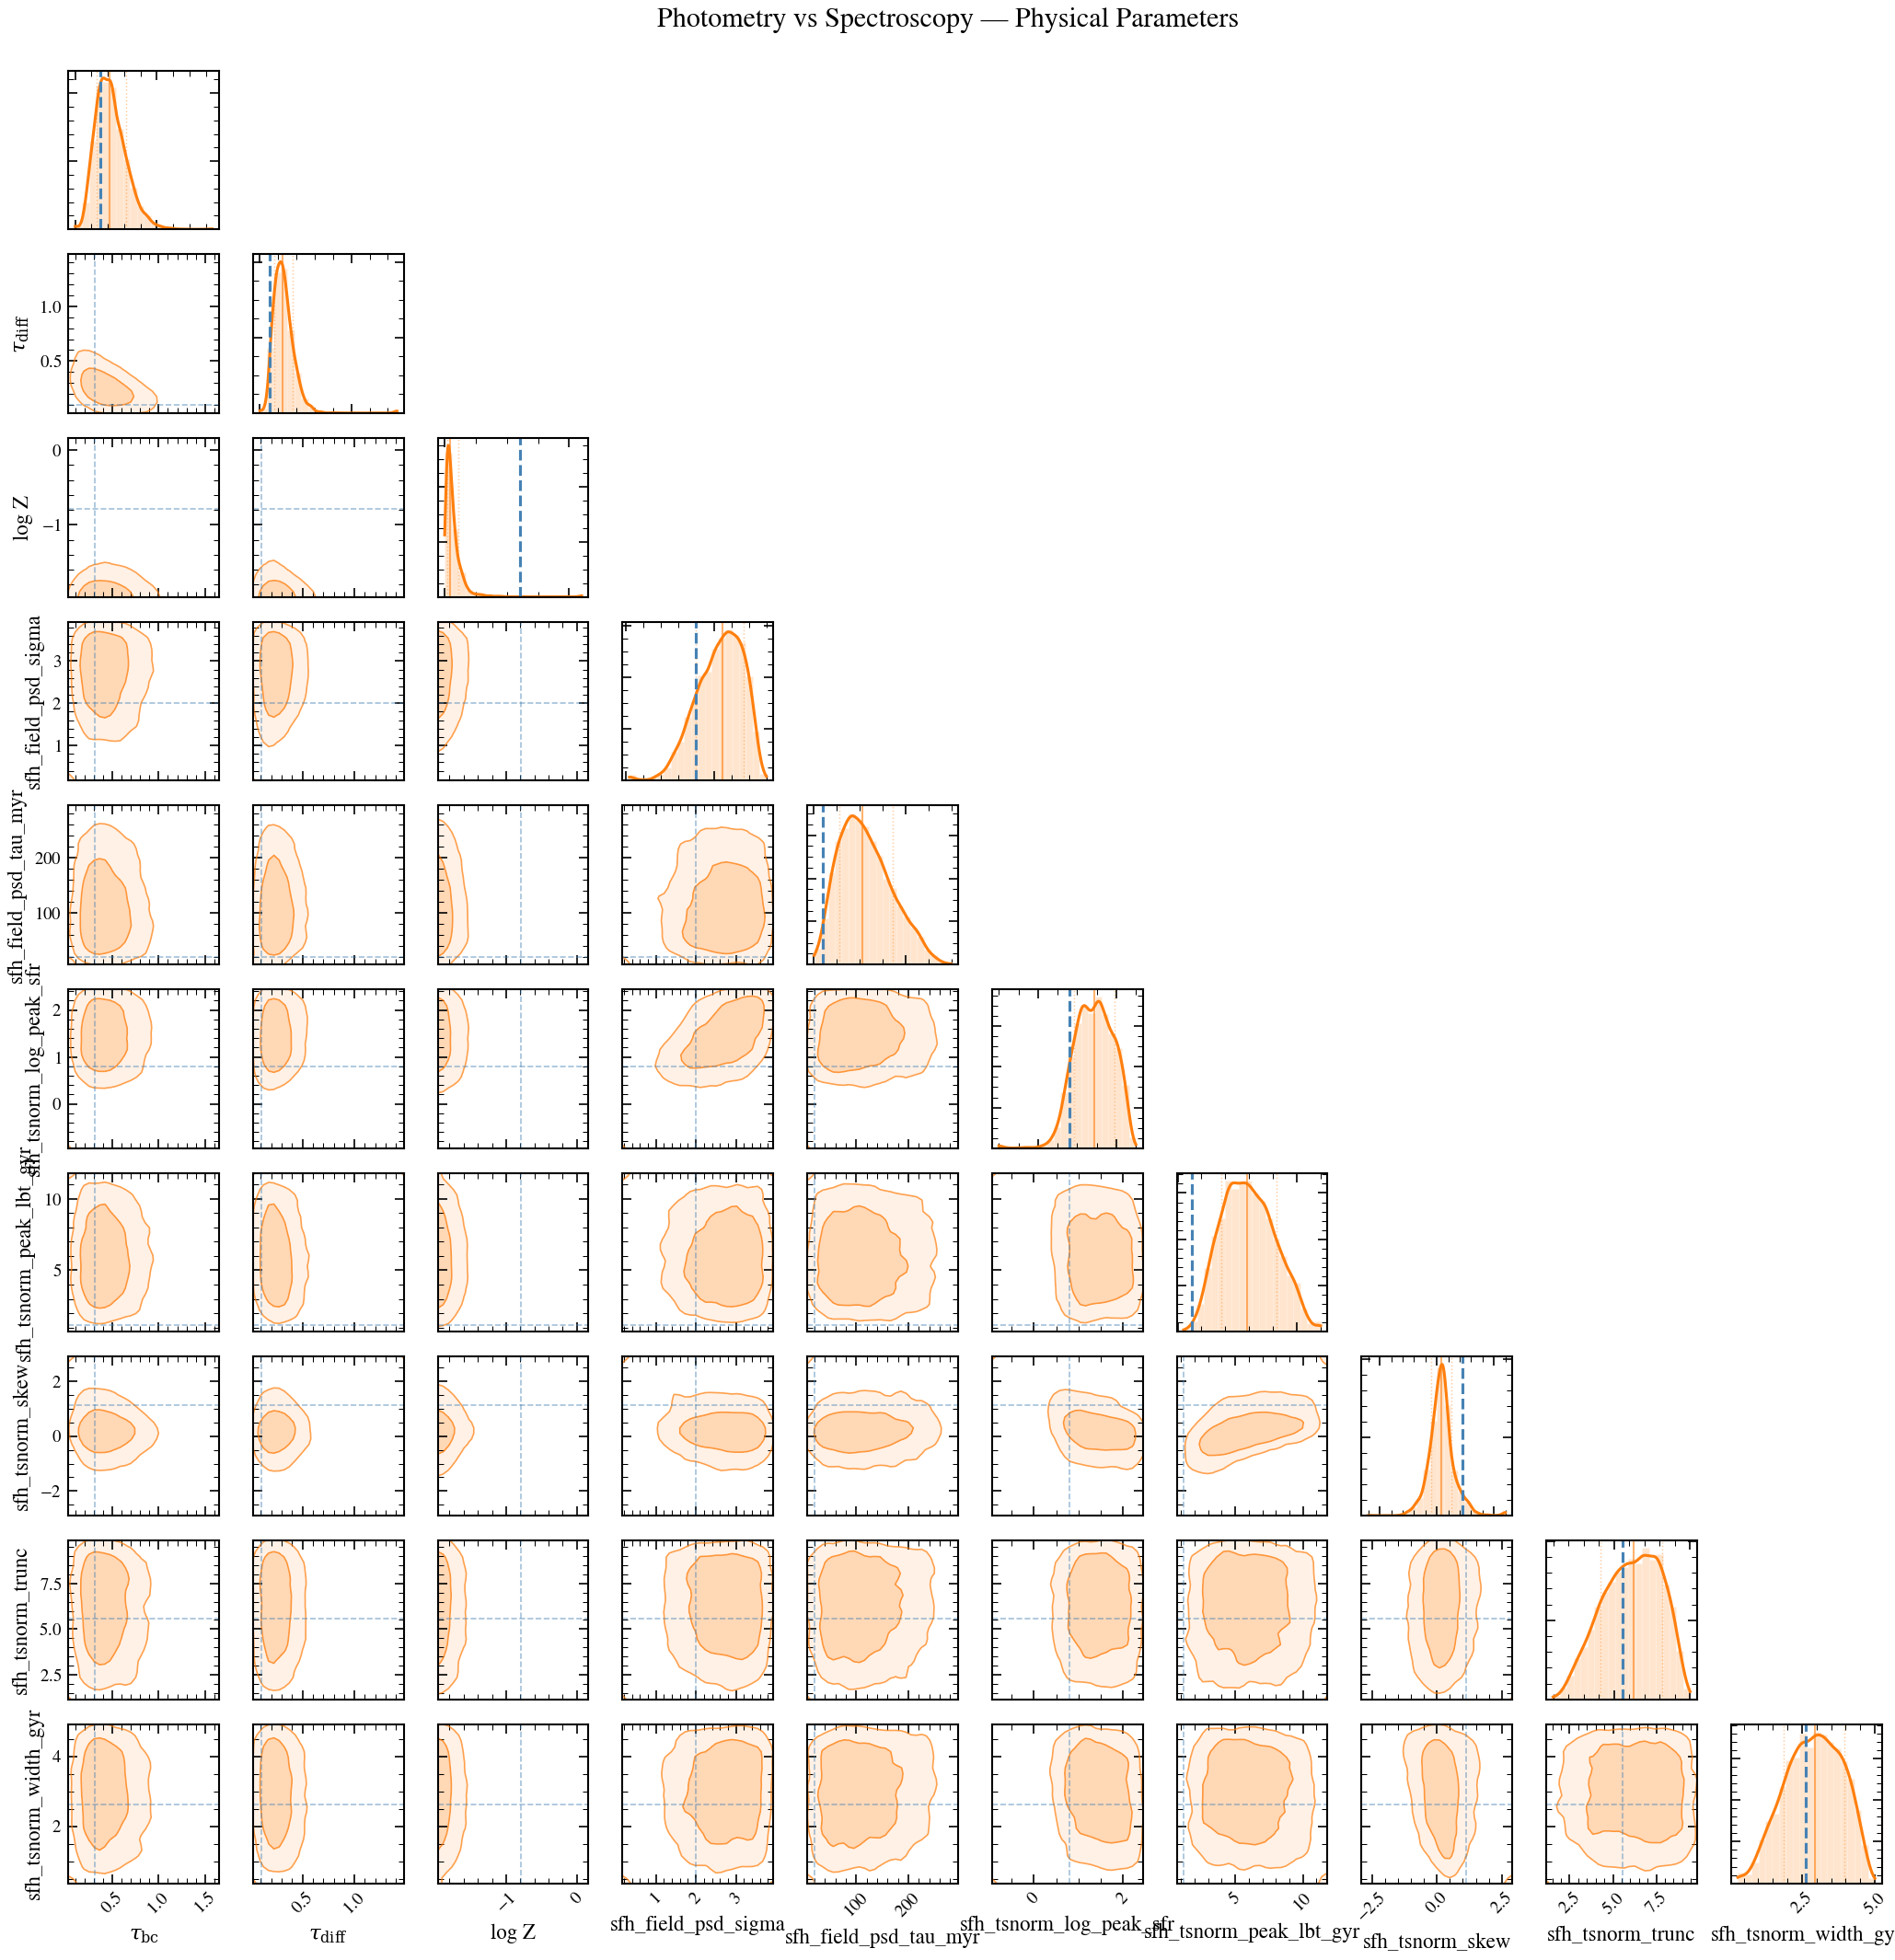

In [14]:
# --- FIGURE 7: Overlaid corners (phot vs spec) ---
phys_params = [p for p in spec_stoch.free_params if "xi" not in p]
fig = plot_corner_comparison(
    [result_stoch_phot, result_stoch_spec],
    labels=["Photometry (5 bands)", "Spectroscopy (200 px)"],
    colors=[COLORS["rt"], COLORS["geovi"]],
    truths=true_stoch,
    params=phys_params,
)
if fig is not None:
    fig.suptitle("Photometry vs Spectroscopy — Physical Parameters", y=1.02)
    plt.savefig(os.path.join(FIGDIR, "fig07_phot_vs_spec_corner.png"), dpi=150, bbox_inches="tight")
plt.show()

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

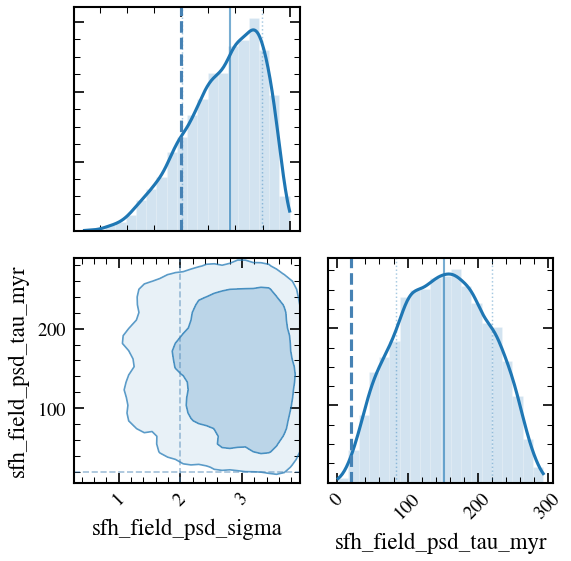

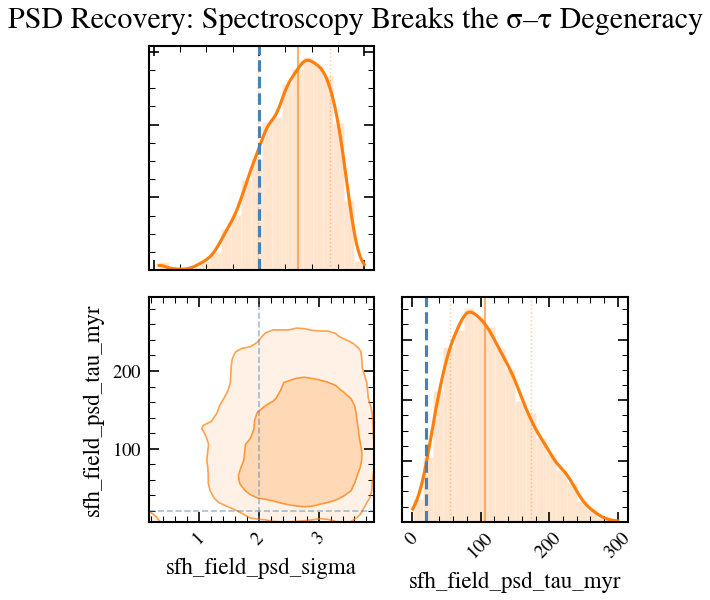

In [15]:
# --- FIGURE 8: PSD corner comparison ---
fig = plot_corner_comparison(
    [result_stoch_phot, result_stoch_spec],
    labels=["Photometry", "Spectroscopy"],
    colors=[COLORS["rt"], COLORS["geovi"]],
    truths=true_stoch,
    params=psd_params,
)
if fig is not None:
    fig.suptitle("PSD Recovery: Spectroscopy Breaks the σ–τ Degeneracy", y=1.02)
    plt.savefig(os.path.join(FIGDIR, "fig08_psd_phot_vs_spec.png"), dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# CI width comparison table
print("\n  Parameter                  | Phot CI   | Spec CI   | Improvement")
print("  " + "-" * 65)
for p in phys_params:
    s_phot = np.array(result_stoch_phot.samples[p])
    s_spec = np.array(result_stoch_spec.samples[p])
    w_phot = np.percentile(s_phot, 84) - np.percentile(s_phot, 16)
    w_spec = np.percentile(s_spec, 84) - np.percentile(s_spec, 16)
    ratio = w_phot / max(w_spec, 1e-10)
    print(f"  {p:<28s} | {w_phot:>7.3f}  | {w_spec:>7.3f}  | {ratio:>5.1f}×")


  Parameter                  | Phot CI   | Spec CI   | Improvement
  -----------------------------------------------------------------
  dust_tau_bc                  |   0.919  |   0.362  |   2.5×
  dust_tau_diff                |   0.302  |   0.201  |   1.5×
  met_logzsol                  |   0.826  |   0.181  |   4.6×
  sfh_field_psd_sigma          |   1.469  |   1.367  |   1.1×
  sfh_field_psd_tau_myr        | 137.673  | 117.691  |   1.2×
  sfh_tsnorm_log_peak_sfr      |   1.144  |   1.032  |   1.1×
  sfh_tsnorm_peak_lbt_gyr      |   5.145  |   4.635  |   1.1×
  sfh_tsnorm_skew              |   2.292  |   0.906  |   2.5×
  sfh_tsnorm_trunc             |   4.117  |   4.062  |   1.0×
  sfh_tsnorm_width_gyr         |   2.121  |   2.066  |   1.0×


## SNR Dependence

In [17]:
# Fit at SNR = 10, 30, 100
snr_results = {}
for snr in [10, 30, 100]:
    mock_snr = model_param.mock_spectrum(
        true_param, WAVE_OBS, snr=float(snr), key=jax.random.PRNGKey(snr)
    )
    fitter_snr = Fitter(
        model_param, mock_snr.flux_obs, mock_snr.noise, data_type="spectroscopy"
    )
    _ = fitter_snr.run("map", n_steps=500, verbose=False)
    res_snr = fitter_snr.run(
        "native_geovi", n_iterations=15, n_samples=6, n_seeds=3,
        n_posterior_samples=2000, verbose=False,
    )
    snr_results[snr] = res_snr
    print(f"SNR = {snr}: {res_snr.wall_time_s:.1f}s")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0321 13:30:02.061686 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 13:30:15.487611 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


W0321 13:32:07.505016 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 13:32:22.140978 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 13:32:37.989878 14663711 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


SNR = 100: 71.3s


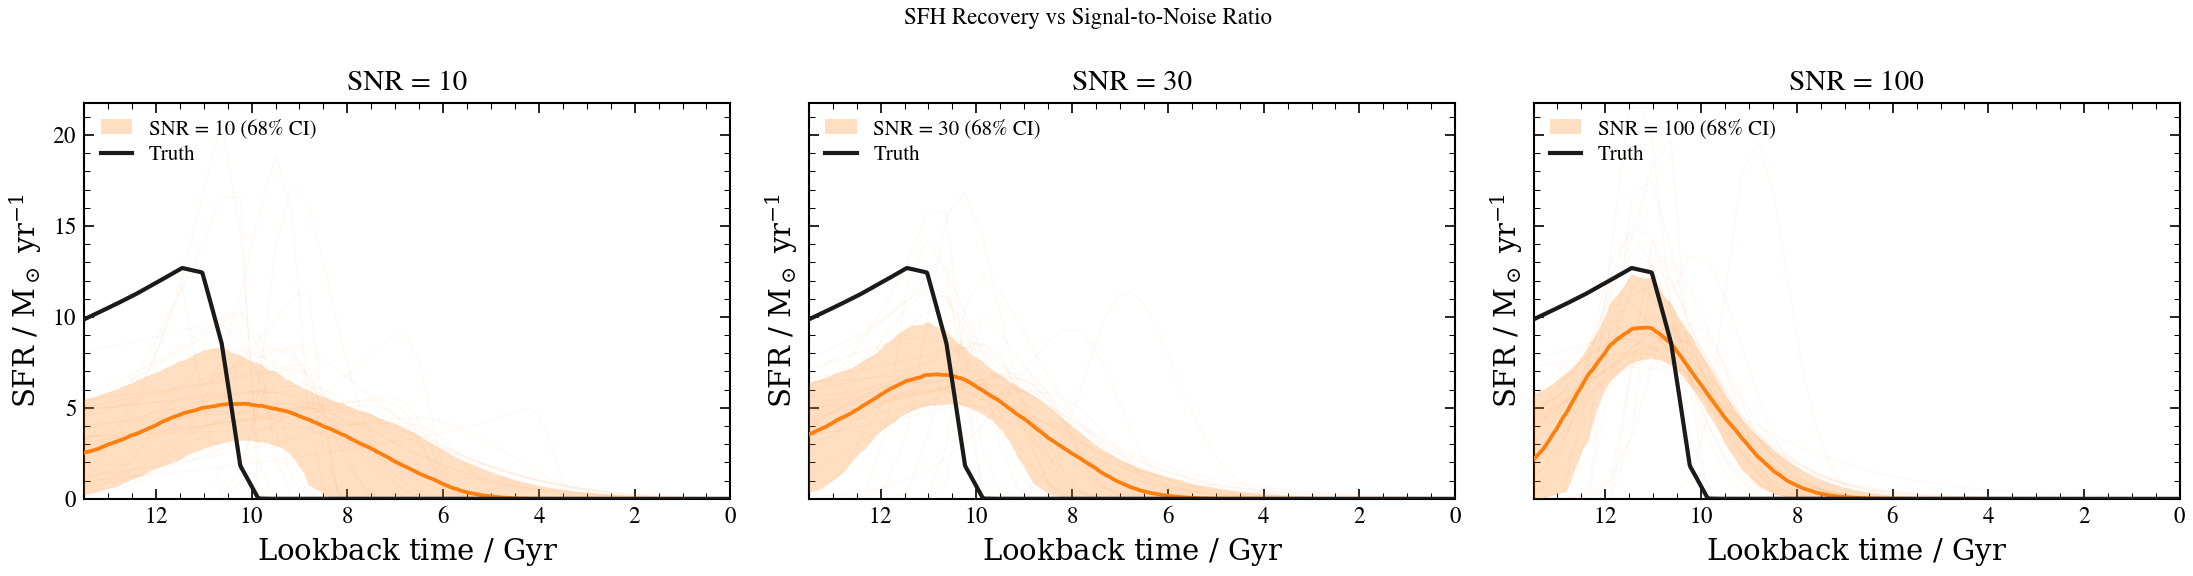

In [18]:
# --- FIGURE 9: SFH recovery at 3 SNR values ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, snr in zip(axes, [10, 30, 100]):
    plot_sfh(model_param, snr_results[snr], true_params=true_param, ax=ax,
             color=COLORS["geovi"], label=f"SNR = {snr}", method="geoVI")
    ax.set_title(f"SNR = {snr}")
fig.suptitle("SFH Recovery vs Signal-to-Noise Ratio", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig09_snr_dependence.png"), dpi=150, bbox_inches="tight")
plt.show()

## Feature Accessibility vs Redshift

As redshift increases, different spectral features shift through the
observed window. At z > 5, the Lyman break enters the NIR — JWST territory.

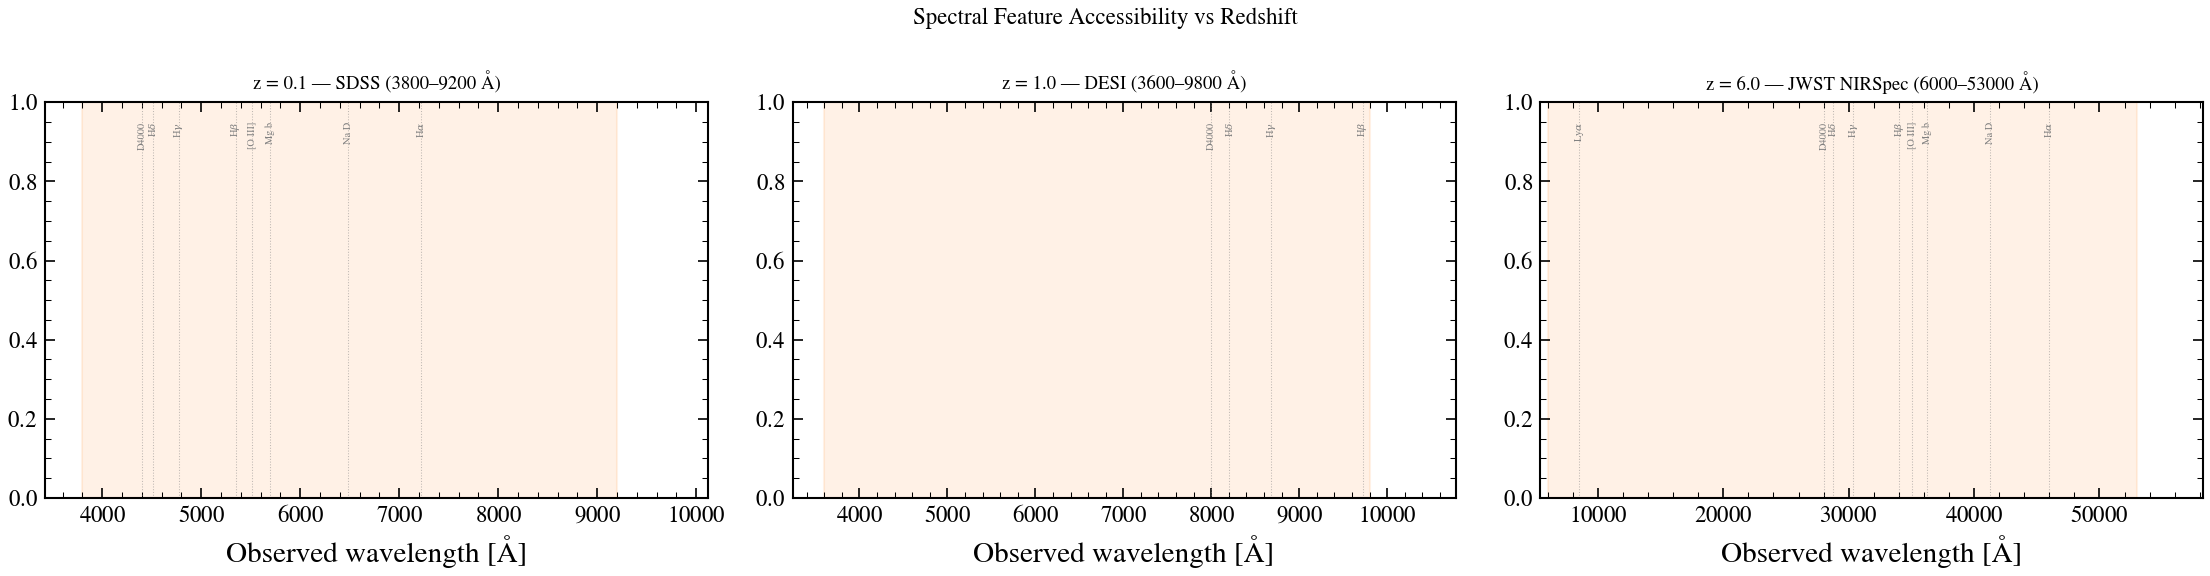

In [19]:
# --- FIGURE 10: Rest-frame features at z = 0.1, 1.0, 6.0 ---
redshifts = [0.1, 1.0, 6.0]
surveys = ["SDSS (3800–9200 Å)", "DESI (3600–9800 Å)", "JWST NIRSpec (6000–53000 Å)"]
windows = [(3800, 9200), (3600, 9800), (6000, 53000)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, z, survey, (wlo, whi) in zip(axes, redshifts, surveys, windows):
    # Mark features in rest-frame
    for feat_name, feat_wave in SPECTRAL_FEATURES.items():
        w_obs = feat_wave * (1 + z)
        if wlo < w_obs < whi:
            ax.axvline(w_obs, color="grey", ls=":", lw=0.5, alpha=0.5)
            ax.text(w_obs, 0.95, feat_name, fontsize=5, ha="center", va="top",
                    rotation=90, transform=ax.get_xaxis_transform(), color="grey")

    ax.axvspan(wlo, whi, alpha=0.1, color=COLORS["geovi"])
    ax.set_xlabel("Observed wavelength [Å]")
    ax.set_title(f"z = {z} — {survey}", fontsize=9)
    ax.set_xlim(wlo * 0.9, whi * 1.1)

fig.suptitle("Spectral Feature Accessibility vs Redshift", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig10_redshift_accessibility.png"), dpi=150, bbox_inches="tight")
plt.show()

## Practical Checklist

1. **Always run MAP first** — gives a sensible starting point.
2. **Check residuals** — reduced χ² ≈ 1, no systematic patterns.
3. **Mask bad pixels** — telluric absorption, sky lines, detector artifacts.
4. **Match resolution** — convolve templates to data resolution if needed.
5. **Wavelength-dependent noise** — use per-pixel uncertainties, not global SNR.
6. **Emission lines** — consider line marginalization for strong emitters.
7. **Convergence diagnostics** — ESS > 100, no divergences.